# S9 — Robustez e limitações

Esta etapa é reporting-only e pós-confirmatória. Ela consome apenas os resumos persistidos de S6, S7 e S8. A conclusão confirmatória permanece: delta UpliftTree − baseline de propensão = -0,0088447, IC95% [-0,0491571, 0,0302486]; não há evidência confirmatória de vantagem.

O objetivo é registrar o que permanece estável, o que é sensível e por que o material ainda não está pronto para implantação direta. Budgets, cenários e comparações secundárias são tratados como exploração, não como testes confirmatórios independentes.

## Índice

- [Registro e fronteira de decisão](#s9-1)

---

In [1]:
from pathlib import Path
import logging
import os
import sys
logging.getLogger("duecredit").setLevel(logging.CRITICAL)
os.environ["LOKY_MAX_CPU_COUNT"] = "1"
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = next(parent for parent in PROJECT_ROOT.parents if (parent / "src").exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.config import PROJECT_ROOT as CONFIG_PROJECT_ROOT
from src.i18n import make_lang
from src.robustness_reports import (
    build_s9_report, display_s9_report, load_s9_inputs,
    plot_s9_report, save_s9_artifacts,
)
PROJECT_ROOT = CONFIG_PROJECT_ROOT
ARTIFACTS_S9_DIR = PROJECT_ROOT / "artifacts" / "s9"
lang = make_lang('pt')


<a id="s9-1"></a>

## Registro e fronteira de decisão

O registro separa a evidência confirmatória de S6 da evidência exploratória de S7/S8. O resumo de robustez conta sinais e intervalos por curva inteira; não transforma cada budget em um teste independente nem escolhe o maior resultado. A economia permanece ilustrativa, e a decisão permitida é aprendizado e desenho de piloto prospectivo randomizado.

S9 — Robustez e limitações | não pronto para implantação direta
Registro de evidências
             evidence_id stage evidence_class                                      claim  estimate    ci_low  ci_high                     status                                                                                                     interpretation
              S6_primary    S6  Confirmatória         UpliftTree - baseline de propensão -0.008845 -0.049157 0.030249 Sem vantagem confirmatória                                                       O IC95% inclui zero; a hipótese primária não foi confirmada.
               S7_funnel    S7   Exploratória Heterogeneidade e ranking no outcome visit  0.061529       NaN      NaN         Somente descritivo                                                  A curva é exploratória e não substitui a avaliação confirmatória.
S7_visit_spend_alignment    S7   Exploratória    Correlação entre rankings visit e spend  0.094127       NaN      NaN          Baixo 

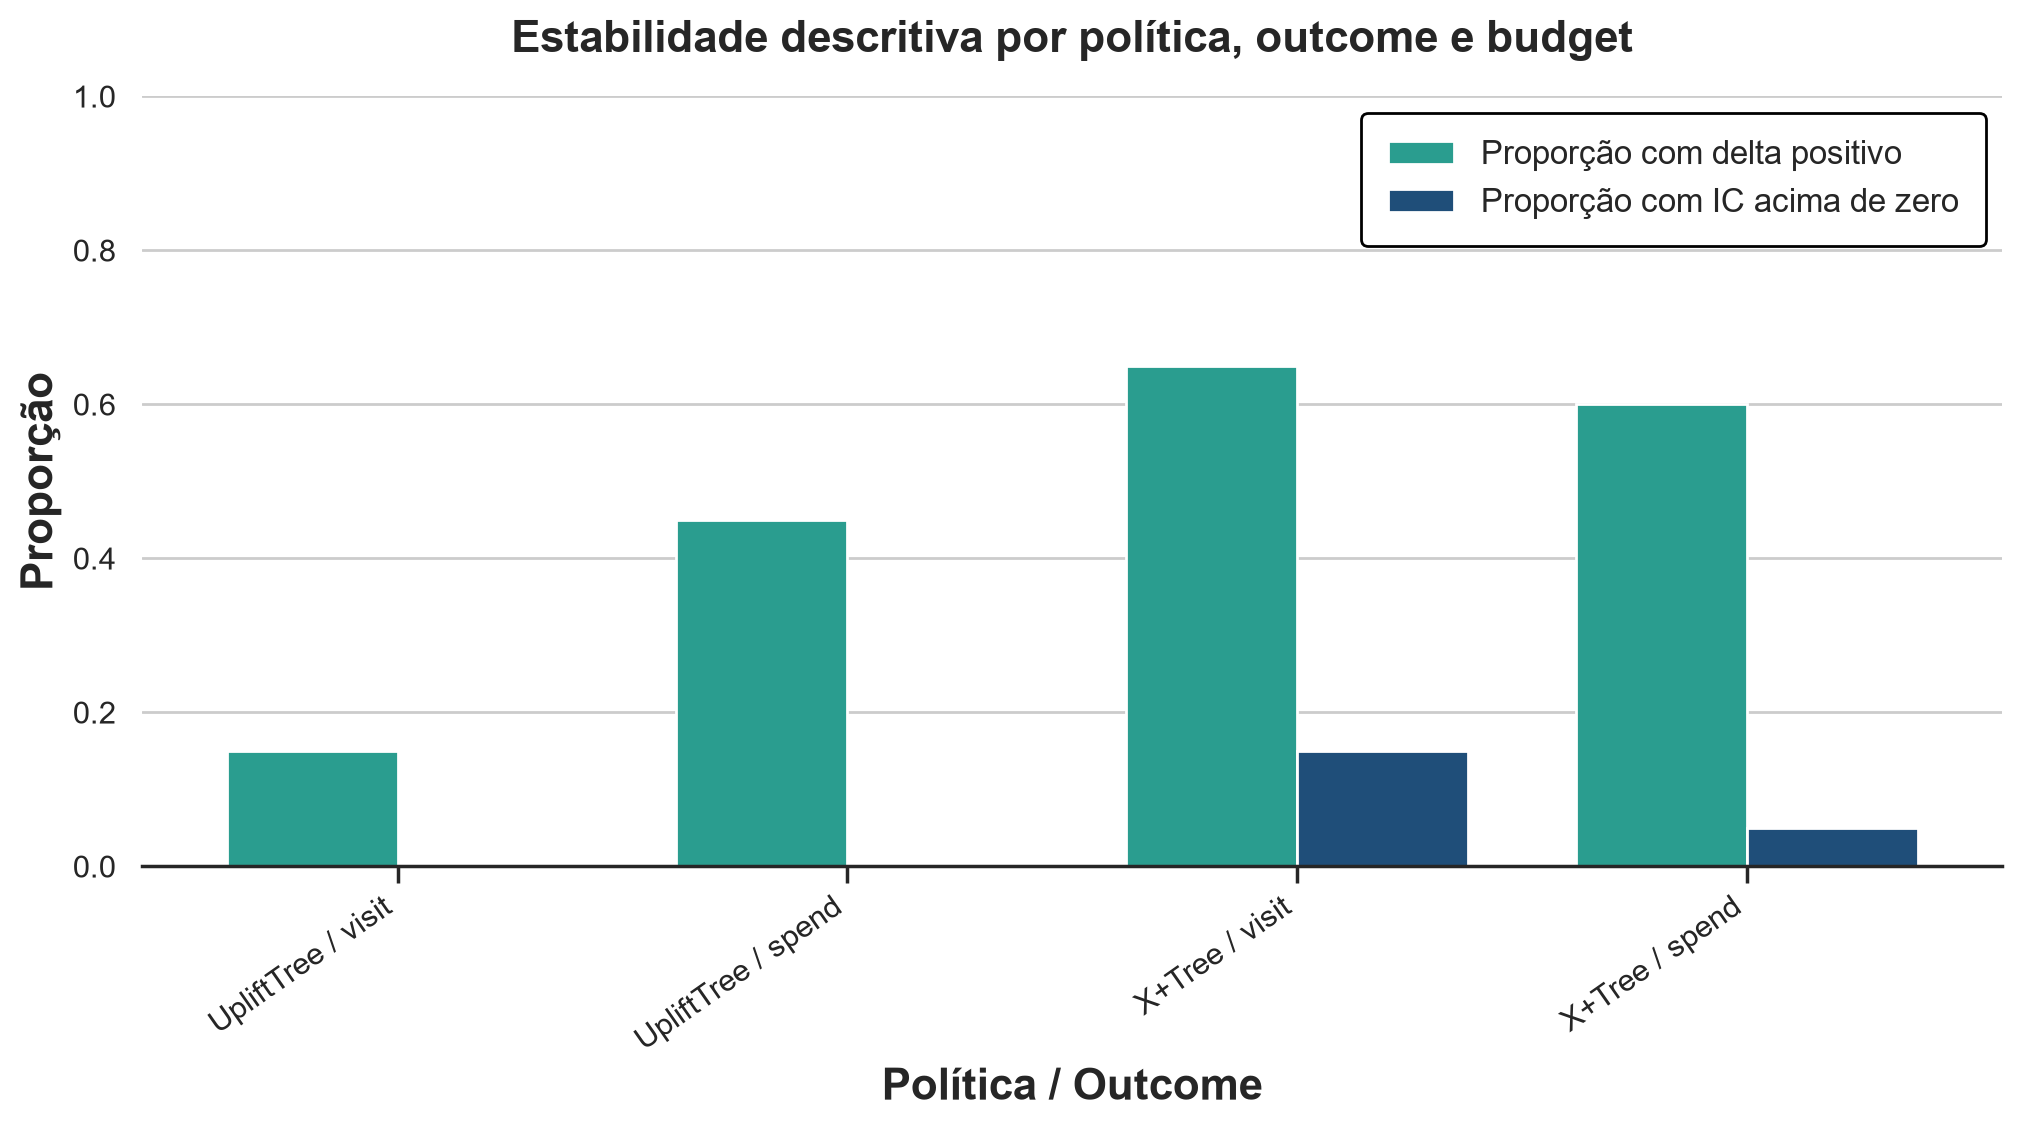

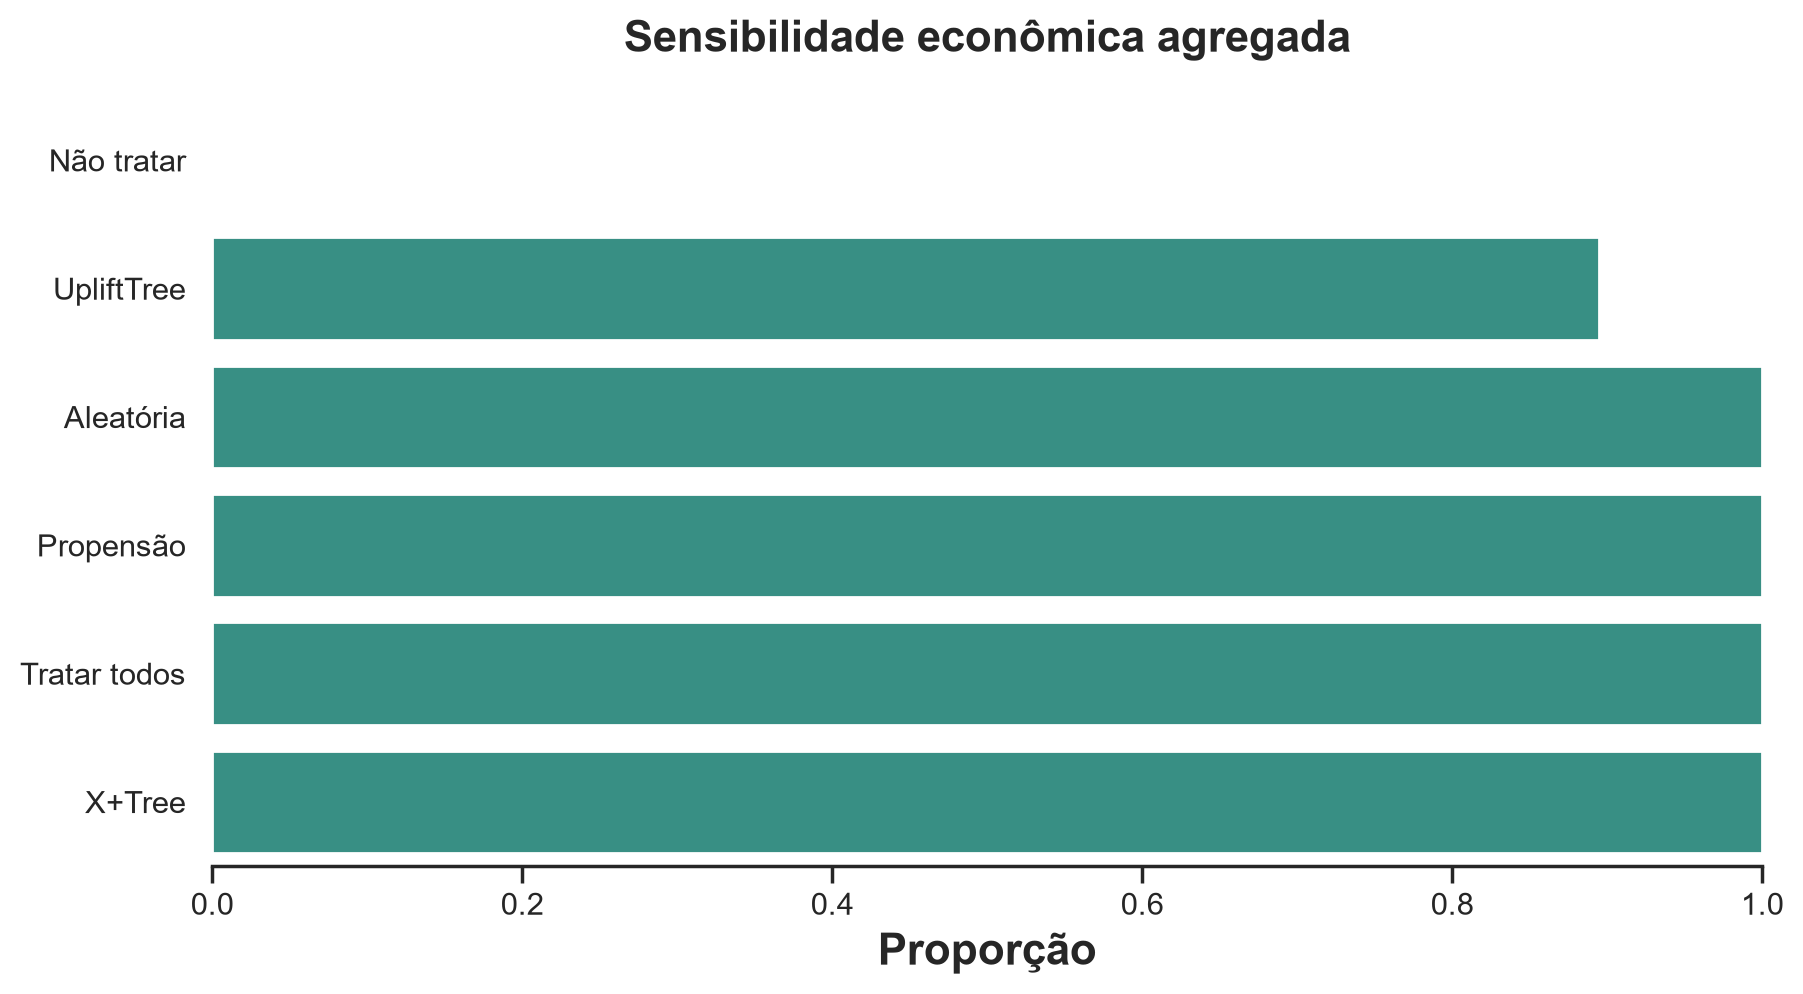

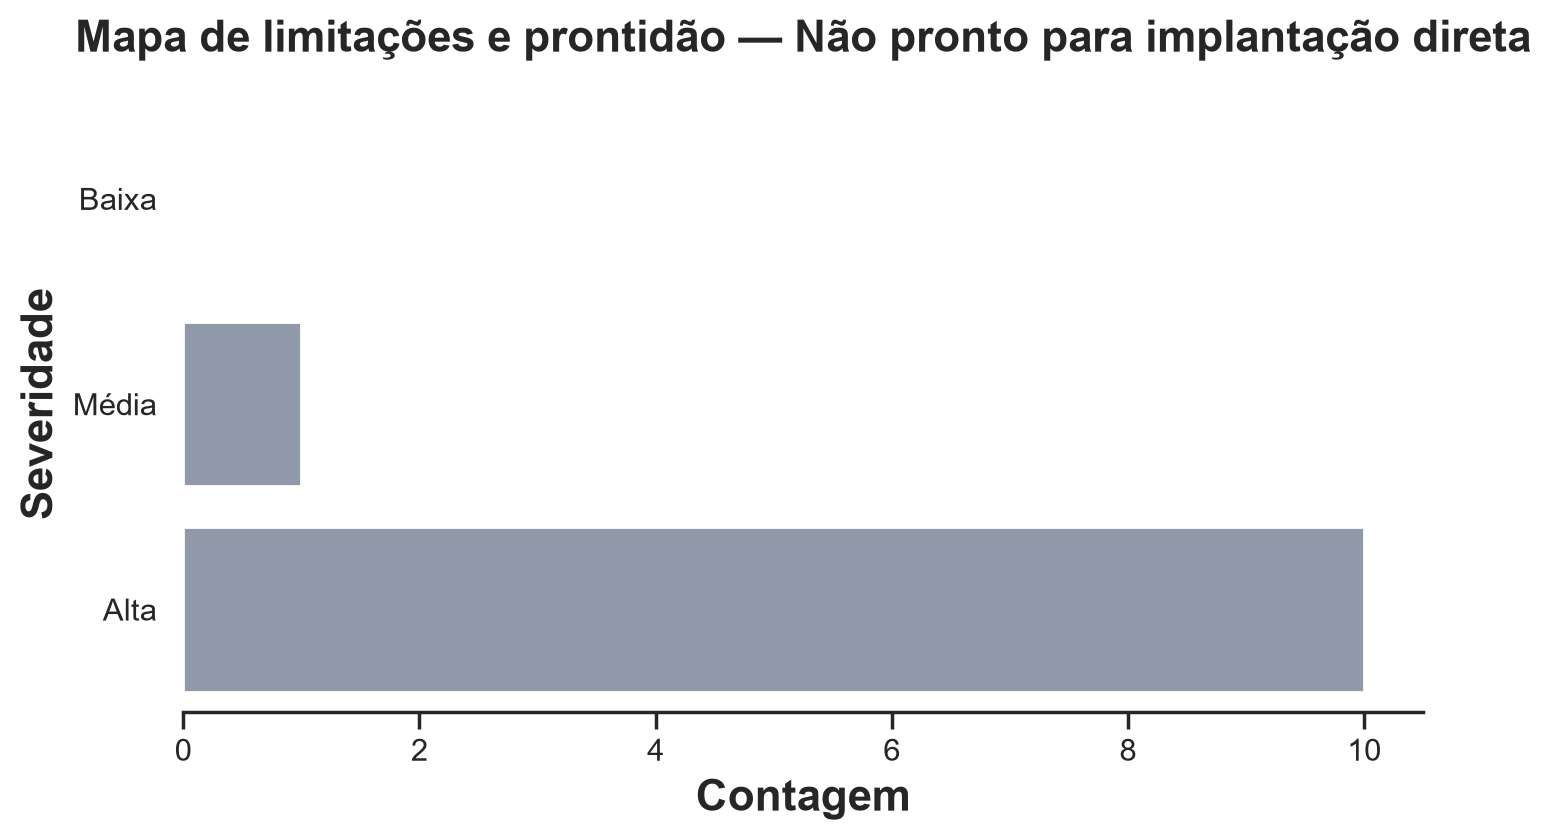

In [2]:
inputs = load_s9_inputs(PROJECT_ROOT / "artifacts")
report = build_s9_report(inputs)
save_s9_artifacts(report, ARTIFACTS_S9_DIR)
display_s9_report(report, lang=lang, artifacts_dir=ARTIFACTS_S9_DIR)
figures = plot_s9_report(report, lang=lang, show=True)
